# Chapter 1: Deep Learning

In the previous chapter, we saw how to automatically generate text using Markov chains. We also saw that one of the problems with this approach is that it is impractical to capture long-term dependencies due to the combinatorial explosion of the number of states. In this chapter, we will explore the basis that will enable us to solve this and other problems. Why, if instead of writing the algorithm to solve the problem, we write a learning strategy that can learn to solve problems from data? The method we start with is inspired by how our brain processes information.

<img src="./neuron.png" alt="Neuron" width="800" height="400">

## A single neuron

Let's start simple, and later we will see how we can simulate a neuron to learn from data.

Consider the function $f(x) = w \cdot x + b$. How can we automatically find the values of $w$ and $b$ that make $f(2) = 5$? Let's start with $w = 1$ and $b = 1$ and see how we can improve from there.

In [1]:
# our input
x = 2
# our expected value
y = 5

# our function parameters
w = 1
b = 1

# our function
def f(x):
    return w * x + b

# let's test it
o = f(x)

print(o)

3


Ok, we expected to have 5, but our function returned 3. Let's compute how distant our output is from the expected value. Let's call this the error of our function. We can simply compute the error as $error = expected - predicted$, or $error = y - o$.

In [2]:
# the error of our prediction
error = y - o

print(error)

2


Computing our error, we get 2. If the predicted value is higher than the expected value, we will get a negative error. We don't want that since the error is the distance between the expected and the predicted value, and we want positive distances. We can solve this by simply squaring the error as $error = (y - o) ^ 2$. This way, we will always get a positive error, and the error will be higher the more distant the predicted value is from the expected value. The error function is also known as the loss function.

In [3]:
loss = (y - o) ** 2

print(loss)

4


Now, let's plot the error function and see where our predicted value error lies in this function.

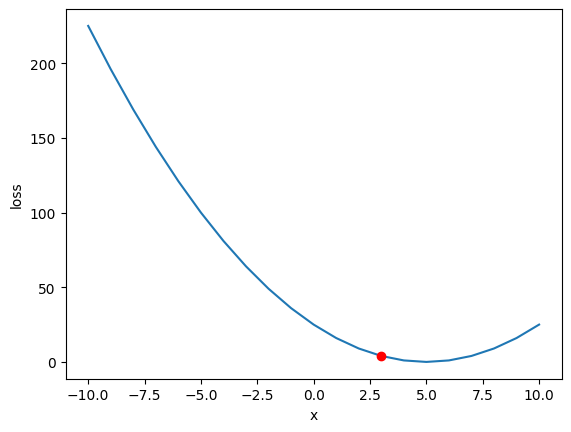

In [4]:
import matplotlib.pyplot as plt

# plotting the loss function
e = [(y - i) ** 2 for i in range(-10, 11)]
plt.plot(range(-10, 11), e, zorder=1)

# plotting our predicted value loss
plt.scatter(o, loss, color='red', zorder=2)
plt.xlabel('x')
plt.ylabel('loss')

plt.show()

If we have a way to discover how to change our values $w$ and $b$ to make the function give a function output closer to the expected value. By doing that, we will decrease our loss, and we will be able to find the function we want. In this sense, reducing the loss function is the same as finding the function we want. The good news is that we can borrow the concepts of derivatives from calculus to solve this. The derivative of a function gives us the slope of the function at a given point. This slope shows us how the function changes if we change our inputs. You can find more about derivatives [here](https://www.khanacademy.org/math/differential-calculus/dc-diff-intro/dc-diff-calc-intro/v/newton-leibniz-and-usain-bolt).

The derivative of our loss function, as it is an exponential, is defined as $n \cdot x^{n-1}$ where $n$ is the exponent and $x$ is the base. In our case, the base is also a function, and to derive a function of a function, we need to apply the chain rule, which is defined as $f(g(x))' = f'(g(x)) \cdot g'(x)$. In our case $f(x) = x^2$ and $g(x) = y - o$. So we have that the derivative of our loss function is $2(y - o) \cdot d(y - o)$. Since $y$ is a constant and in this case the output is our variable and the derivative of a variable is 1, we have that $d(y - o) = -1$. So we have that the derivative of our loss function is $-2(y - o)$.

Let's see what this derivative looks like in our loss function plot.

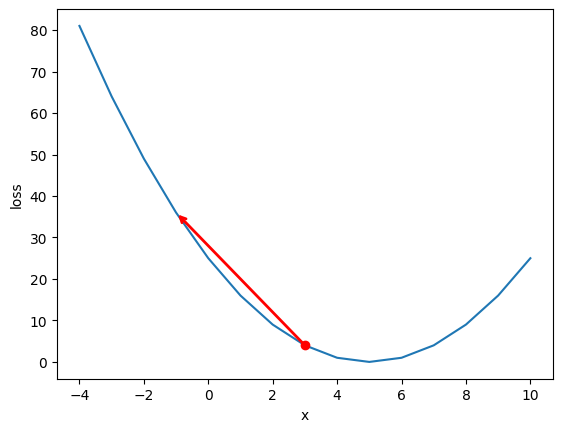

In [5]:
# our loss derivative
d_loss = -2 * (y - o)

# plotting the loss function
e = [(y - i) ** 2 for i in range(-4, 11)]
plt.plot(range(-4, 11), e, zorder=1)

# plotting the expected value loss
plt.scatter(o, loss, color='red', zorder=2)
plt.xlabel('x')
plt.ylabel('loss')

# drawing an arrow to show the direction of the change of the loss function from the predicted value
plt.annotate(
    "",
    xy=(o + d_loss, (y - (o + d_loss)) ** 2),      # arrow tip
    xytext=(o, loss),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='red'),
)

plt.show()

The derivative in this case shows how to increase the loss function. This change in direction from a point is called the gradient. Since the gradient is showing us the direction of steepest increase in our function, we can take the opposite direction to get the steepest decrease in our function.

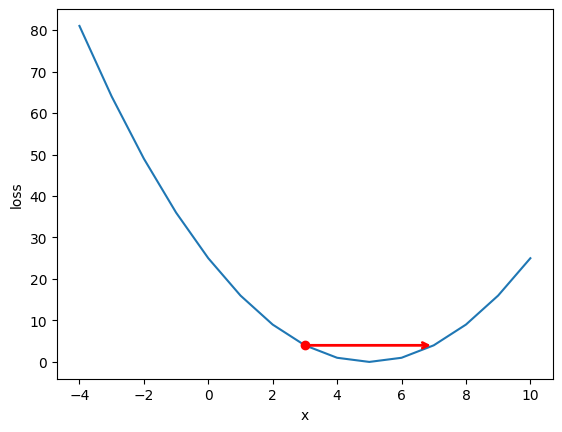

In [6]:
# our loss derivative
d_loss = -2 * (y - o)

# plotting the loss function
e = [(y - i) ** 2 for i in range(-4, 11)]
plt.plot(range(-4, 11), e, zorder=1)
plt.xlabel('x')
plt.ylabel('loss')

# plotting the expected value loss
plt.scatter(o, loss, color='red', zorder=2)

# multiplying the gradient by -1 to get the direction of steepest decrease in our function
plt.annotate(
    "",
    xy=(o - d_loss, (y - (o - d_loss)) ** 2),      # arrow tip
    xytext=(o, loss),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='red'),
)

plt.show()

We took a large jump in the direction of decreasing our function. However, this throws us far away from the expected value. This can cause a problem of constantly missing the target and never minimizing our loss function.

To avoid this, we can take smaller steps in the direction of decreasing our function, leading it to convergence.

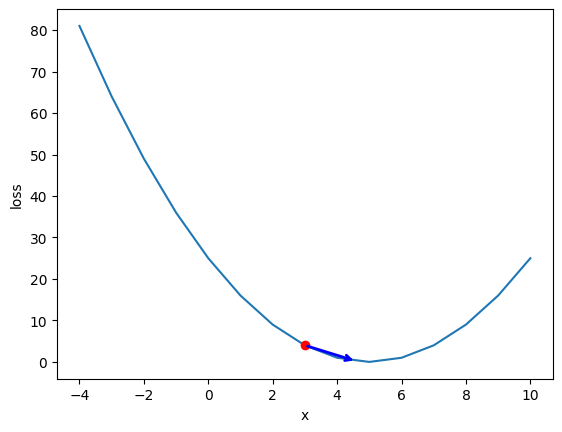

In [7]:
# our loss derivative
d_loss = -2 * (y - o)

# reducing the step size to get closer to the expected value
d_loss *= 0.4

# plotting the loss function
e = [(y - i) ** 2 for i in range(-4, 11)]
plt.plot(range(-4, 11), e, zorder=1)
plt.xlabel('x')
plt.ylabel('loss')

# plotting the expected value loss
plt.scatter(o, loss, color='red', zorder=2)

# multiplying the gradient by -1 to get the direction of steepest decrease in our function
plt.annotate(
    "",
    xy=(o - d_loss, (y - (o - d_loss)) ** 2),      # arrow tip
    xytext=(o, loss),  # arrow start
    arrowprops=dict(arrowstyle="->", linewidth=2, color='blue'),
)

plt.show()

The name of this optimization technique is gradient descent, and we can use it to learn the right parameters of our function. The problem is that the gradient is defined for functions with only one variable. And we have $w$ and $b$ to change. To solve this, we can compute the partial derivatives instead of the total derivative. The partial derivative of a function with respect to a variable computes how a function changes if we change only that variable. Computing it is similar to computing the total derivative, but we consider the other values as constants. More about partial derivatives [here](https://www.khanacademy.org/math/multivariable-calculus/multivariable-derivatives/partial-derivative-and-gradient-articles/a/introduction-to-partial-derivatives).

### The chain rule

We know that with partial derivatives, we can compute the change in our variables. But how can we compute the partial derivative of our loss function with respect to $w$? We know how to compute how the loss function changes when the output changes. But how can we compute how the loss changes if we change $w$? We can use the chain rule to solve this:

$$ \frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} $$

This formula can be frightening at first glance. But what it is telling us is that the derivative of a function is computed by mutiplying the local derivatives of a function at each step until we reach the variables we want to change. In our case, we have two steps. The first step is computing how the loss changes if we change the output, and the second step is computing how the output changes if we change $w$. So we have that:

$$ \frac{d(loss)}{dw} = \frac{d(loss)}{do} \cdot \frac{do}{dw} $$

We have to do the same with $b$:

$$ \frac{d(loss)}{db} = \frac{d(loss)}{do} \cdot \frac{do}{db} $$

The good part of this is that we are just multiplying two numbers. And that's it. By computing the gradient of our loss function and adding its negative to our variables, we can reduce our loss and get closer to the expected value. Let's compute those derivatives:

$$ \frac{d(loss)}{dw} = \frac{d(loss)}{do} \cdot \frac{do}{dw} $$

Let's consider that our output is $o$. So we have that:

$$ \frac{d(loss)}{dw} = (y - o)'^2 $$

Applying the chain rule, we have that:

$$ \frac{d(loss)}{dw} = 2(y - o) * (y - o)' $$

The $y$ is a constant, and its derivative is 0. Let's replace $o$ in the formula to compute its derivative with respect to $w$:

$$ \frac{d(loss)}{dw} = 2(y - o) * (0 - (wx + b)') $$

The derivative of the sum is the sum of the derivatives, and since b is a constant, its derivative is 0. The derivative of a product is defined as $d(uv) = u'v + uv'$. So we have that:

$$ \frac{d(loss)}{dw} = 2(y - o) * (0 - (w'x + w'x + 0)) $$

Since $w$ is our variable its derivative is 1 and $x$ is constant so its derivative is 0:

$$ \frac{d(loss)}{dw} = 2(y - o) * (0 - (x + 0)) $$

Simplifying, we have that:

$$ \frac{d(loss)}{dw} = -2(y - o) * x $$

Doing the same for $b$ (in fast-forward):

$$ \frac{d(loss)}{db} = -2(y - o) * 1 $$

Now that we have the gradients of our function, we can compute them and update our variables to get closer to the expected value.

In [8]:
# our input
x = 2
# our expected value
y = 5

# our function parameters
w = 1
b = 1

# our function but with the parameters as arguments
def f(x, w, b):
    return w * x + b

# let's test it
o = f(x, w, b)
print('Output:', o)

loss = (y - o) ** 2
print('Loss:', loss)

# Gradient for w
dw = -2 * (y - o) * x
# Gradient for b
db = -2 * (y - o) * 1
print('dw:', dw, 'db:', db)

# adding a small amount of the negative gradient to our variables
a = 0.01

# adding the negative is the same as subtracting
w -= a * dw
b -= a * db

# now testing again
o = f(x, w, b)
print('Output after update:', o)
loss = (y - o) ** 2
print('Loss after update:', loss)

Output: 3
Loss: 4
dw: -8 db: -4
Output after update: 3.2
Loss after update: 3.2399999999999993


Our output is now closer to the expected value, and our loss is smaller. Let's repeat this process a few times and see how the loss drops.

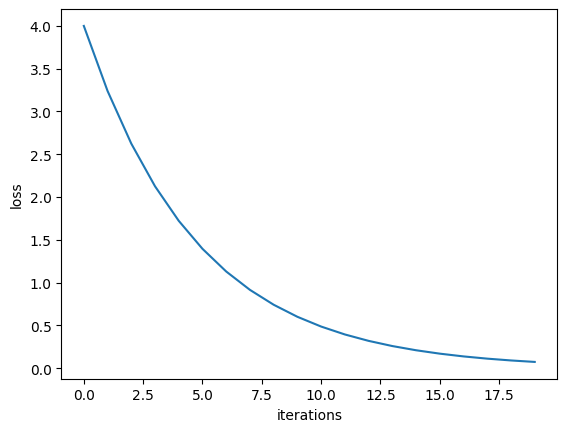

In [9]:
x = 2
y = 5

w = 1
b = 1

def f(x, w, b):
    return w * x + b

# scale of our gradients
a = 0.01

error_history = []

iterations = 20
for _ in range(iterations):
    o = f(x, w, b)
    error_sqr = (y - o) ** 2
    error_history.append(error_sqr)

    # Gradient for w
    dw = -2 * (y - o) * x
    # Gradient for b
    db = -2 * (y - o) * 1

    # gradient descent step
    w -= a * dw
    b -= a * db

plt.plot(error_history)
plt.xlabel('iterations')
plt.ylabel('loss')
plt.show()

Our loss drops to almost 0 after 20 iterations. Those iterations over our dataset are known as epochs. Each epoch is one iteration over the entire dataset.

Let's see the final output of our function with the learned parameters.

In [10]:
print(f'Learned parameters: w={w:.2f}, b={b:.2f}')
print(f'Final output: {f(x, w, b):.2f}')

Learned parameters: w=1.70, b=1.35
Final output: 4.76


Our approach works for one value. But if we have multiple target values? For example, if we have a dataset of 50 points and we want to learn the parameters of a function that fits those points. Instead, we compute the average loss over the dataset. The gradient of the average loss can be computed by averaging the gradients of the loss for each point in the dataset. This way, we can learn the parameters of a function that fits our dataset. Let's see how this works in practice.

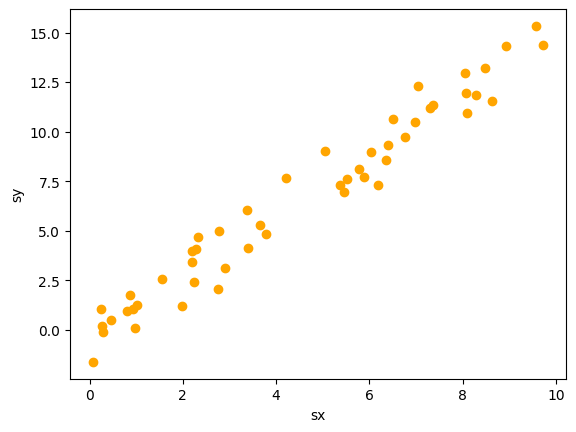

In [11]:
import random

random.seed(42)

# randomly generating a dataset of 50 points
sx = [random.random() * 10 for _ in range(50)]
sy = [random.normalvariate() for _ in range(50)]
sy = [1.5 * x + y for x, y in zip(sx, sy)]

plt.scatter(sx, sy, color='orange', zorder=2)
plt.xlabel('sx')
plt.ylabel('sy')
plt.show()

We generated 50 points in a linear distribution with some noise. Since our function describes a line, we can find the parameters that fit this line. Let's start with $w = 0$ and $b = 5$ and see how the line fits our data.

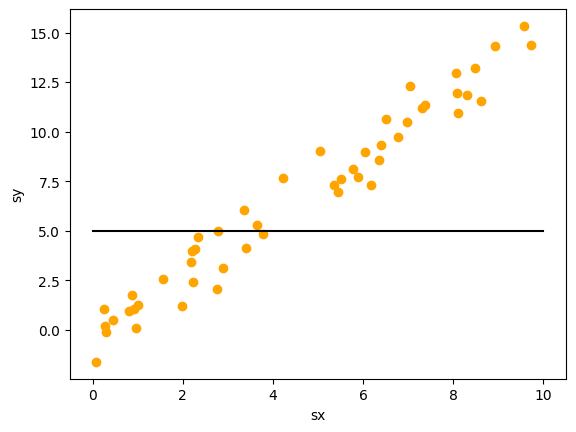

In [12]:
# plotting the data
plt.scatter(sx, sy, color='orange', zorder=1)
plt.xlabel('sx')
plt.ylabel('sy')

# our data parameters
w = 0
b = 5

# plotting our line
line = [f(i, w, b) for i in range(11)]

plt.plot(range(11), line, color='black', zorder=2)
plt.show()

The starting line doesn't fit our data. Now let's apply gradient descent to learn the parameters of the line that best fits our data. We will repeat this process for 400 iterations and see how the line fits our data.

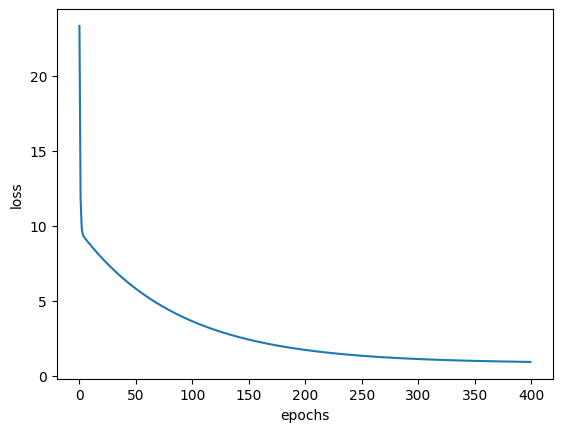

Learned parameters: w=1.45, b=0.18


In [13]:
w = 0
b = 5

a = 0.01

epochs = 400
loss_history = []

for _ in range(epochs):
    # accumulated gradients
    gw = 0
    gb = 0
    # epoch loss
    el = []
    for x1, y1 in zip(sx, sy):
        o = f(x1, w, b)
        loss = (y1 - o) ** 2
        el.append(loss)

        # Gradient for w
        gw += -2 * (y1 - o) * x1

        # Gradient for b
        gb += -2 * (y1 - o)

    # scale by the number of points in the dataset
    w -= a * gw / len(sx)
    b -= a * gb / len(sx)

    loss_history.append(sum(el) / len(el))

plt.plot(loss_history)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

print(f'Learned parameters: w={w:.2f}, b={b:.2f}')

One of the indicators of the success of our approach is that the loss is going down, and that means that we are close to our objective.

Now let's see how the line with the learned parameters fits our data.

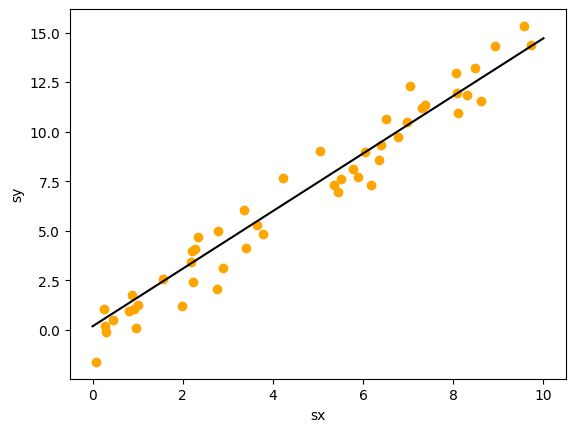

In [14]:
plt.scatter(sx, sy, color='orange', zorder=1)
plt.xlabel('sx')
plt.ylabel('sy')

line = [f(i, w, b) for i in range(11)]

plt.plot(range(11), line, color='black', zorder=2)
plt.show()

The learned function fits the data better than the initial function. This task is also known as linear regression, and it is one of the most basic tasks in machine learning. In this case, our line have oly one dimension. Now let's extend this technique to multidimensional data.

## The Perceptron

Remember when we discussed simulating a neuron at the beginning of this chapter? Biological neurons receive multiple inputs from other neurons, weight then, and emit an activation signal. We will simulate this behaviour by having a weighted sum of the inputs and then adding a constant. This is the same as our linear function, but with more inputs. This model is called a Perceptron. The input values are multiplied by weights, and then we add a constant called bias.

Let's build a Perceptron with two inputs. Also, let's create a class to better organize this model.

In [15]:
class Perceptron:
    def __init__(self):
        # weights
        self.w1 = 0
        self.w2 = 0

        # bias
        self.b = 0

    def forward(self, x1, x2):
        # weighted sum of the inputs plus the bias
        return self.w1 * x1 + self.w2 * x2 + self.b

    def backward(self, x1, x2, y, o):
        # a function to compute the gradients with respect to each parameter
        dw1 = -2 * (y - o) * x1
        dw2 = -2 * (y - o) * x2
        db = -2 * (y - o)
        return dw1, dw2, db

Now, let's train this perceptron in the logical AND function. The AND function takes two binary inputs and returns 1 if both inputs are 1 and 0 otherwise:

| x1 | x2 | y |
|----|----|---|
| 0  | 0  | 0 |
| 0  | 1  | 0 |
| 1  | 0  | 0 |
| 1  | 1  | 1 |

Also, let's rename some variables to adapt to the names used in machine learning. The scale of the gradients is called the learning rate since it controls how much we are learning in each step.

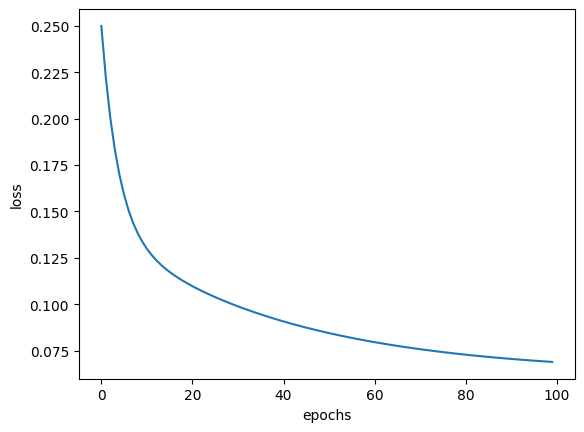

In [16]:
# inputs from AND truth table
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

# expected outputs from AND truth table
y = [0, 0, 0, 1]

# learning rate
lr = 0.01
# our model
perceptron = Perceptron()

epochs = 100

# loss history
lh = []
for _ in range(epochs):
    # accumulated gradients
    gw1 = 0
    gw2 = 0
    gb = 0
    # epoch loss
    el = []
    for (x1, x2), y1 in zip(x, y):
        o = perceptron.forward(x1, x2)
        loss = (y1 - o) ** 2
        el.append(loss)

        # gradients for each parameter
        dw1, dw2, db = perceptron.backward(x1, x2, y1, o)

        gw1 += dw1
        gw2 += dw2
        gb += db

    perceptron.w1 -= a * gw1
    perceptron.w2 -= a * gw2
    perceptron.b -= a * gb
    lh.append(sum(el) / len(el))


plt.plot(lh)
plt.xlabel('epochs')
plt.ylabel('loss')
plt.show()

Our loss goes down. Now, let's see the outputs of the model.

In [17]:
for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

0 0 -> -0.1224
0 1 -> 0.2700
1 0 -> 0.2700
1 1 -> 0.6624


The output of the model is -0.12 when both inputs are 0 and 0.27 when only one of the inputs is 1. When both inputs are 1, the output is 0.66. We can see by those values that the model is struggling to learn the function. Debugging a neural model is often a difficult task. But visualizing the data and how the model is learning can help us to understand what is going on. Let's plot the data and the model parameters to see what is happening.

While having two input variables makes a two-dimensional input, we actually need three dimensions to plot the data corresponding to the expected output. In this case, instead of modeling a line, our model is modeling a plane.

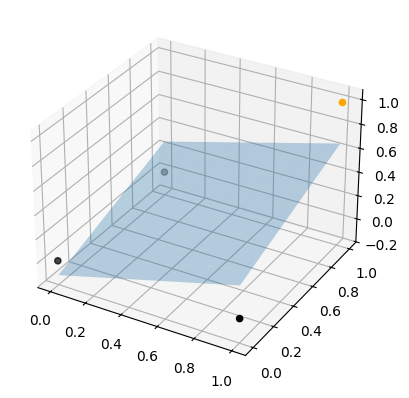

In [18]:
import numpy as np

ax = plt.figure().add_subplot(projection='3d')

ax.scatter([0, 0, 1], [0, 1, 0], [0, 0, 0], color='black')
ax.scatter([1], [1], [1], color='orange')

# create grid
x = np.linspace(0, 1, 10)
y = np.linspace(0, 1, 10)
X, Y = np.meshgrid(x, y)

# plane equation: w1*x + w2*y + b = z
Z = perceptron.w1 * X + perceptron.w2 * Y + perceptron.b

ax.plot_surface(X, Y, Z, alpha=0.3)
plt.show()

We can see in this plot that the model can't increase the output for the point (1, 1) to be 1 without decreasing the output for (0, 0). To solve this, we need to apply a non-linear function to model the data as we expect. One of those functions is the sigmoid function defined as:

$$ \sigma(x) = \frac{1}{1 + e^{-x}} $$

Let's implement this function:

In [19]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

Now we have our function. We can apply it at the end of our perceptron computation to get a non-linear output. This is called an activation function.



In [20]:
class Perceptron:
    def __init__(self):
        self.w1 = 0
        self.w2 = 0
        self.b = 0

    def forward(self, x1, x2):
        h = self.w1 * x1 + self.w2 * x2 + self.b
        # sigmoid activation function
        return sigmoid(h)

We need to compute the gradient of our loss function, but with the sigmoid function applied to the output.

Let's start with our output:

$$ h = w_1x_1 + w_2x_2 + b $$
$$ o = \sigma(h) $$

Now we can compute the loss function:

$$ loss = (y - o) ^ 2 $$

Let's compute the derivative with respect to w_1 and then expand it to the other parameters:

$$ \frac{d loss}{dw_1} = (y - o) ^ 2$$

Applying the chain rule, we have that:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot (y - o)'$$

Expanding the derivative of the output, we have that:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot (0 - \sigma(h)') $$

Now we need to compute the derivative of the sigmoid function to keep applying the chain rule:

$$ \frac{d\sigma}{dx} = \frac{1}{1 + e^{-x}} $$

First, applying the quotient rule:

$$ \frac{d\sigma}{dx} = \frac{(1)'(1 + e^{-x}) - (1)(1 + e^{-x})'}{(1 + e^{-x})^2} $$

Simplifying:

$$ \frac{d\sigma}{dx} = \frac{ e^{-x} }{(1 + e^{-x})(1 + e^{-x})} $$

Now we can rewrite this as:

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot \frac{ e^{-x} }{(1 + e^{-x})} $$

Now with a trick of adding zero to the numerator (1 - 1):

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot \frac{ (1 + e^{-x}) - 1}{(1 + e^{-x})} $$

Rewriting the fractions:

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot \frac{ (1 + e^{-x})}{(1 + e^{-x})} - \frac{ 1 }{(1 + e^{-x})} $$

Replacing the one:

$$ \frac{d\sigma}{dx} = \frac{ 1 }{(1 + e^{-x})} \cdot 1 - \frac{ 1 }{(1 + e^{-x})} $$

Now look what we have:

$$ \frac{d\sigma}{dx} = \sigma(x) \cdot (1 - \sigma(x)) $$

The derivative of the sigmoid is a simple function. That's one of the reasons for choosing it as our activation function. Now we can apply the chain rule once more and compute the derivatives:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -\sigma(h) \cdot (1 - (\sigma(h)) * h' $$

Remember that $ o = \sigma(h) $:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -o \cdot (1 - o) * h' $$

Replacing h:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -o (1 - o) \cdot (w_1x_1 + w_2x_2 + b)' $$

From here, we have the same derivative as before for the linear part:

$$ \frac{d loss}{dw_1} = 2(y - o) \cdot -o (1 - o) \cdot x_1 $$

$$ \frac{d loss}{dw_2} = 2(y - o) \cdot -o (1 - o) \cdot x_2 $$

$$ \frac{d loss}{db} = 2(y - o) \cdot -o (1 - o) $$

Now we can implement our backward function with the new gradients.


In [21]:
def backward(_, x1, x2, y, o):
    dw1 = 2 * (y - o) * (- o * (1 - o) * x1)
    dw2 = 2 * (y - o) * (- o * (1 - o) * x2)
    db = 2 * (y - o) * (- o * (1 - o))
    return dw1, dw2, db

Perceptron.backward = backward

Also, let's put the training code into a function.

In [22]:
def train(model, x, y, lr, epochs):
    lh = []
    for _ in range(epochs):
        gw1 = 0
        gw2 = 0
        gb = 0
        el = []
        for (x1, x2), y1 in zip(x, y):
            o = model.forward(x1, x2)
            loss = (y1 - o) ** 2
            el.append(loss)

            dw1, dw2, db = model.backward(x1, x2, y1, o)

            gw1 += dw1
            gw2 += dw2
            gb += db

        lh.append(sum(el) / len(el))
        model.w1 -= lr * gw1
        model.w2 -= lr * gw2
        model.b -= lr * gb

    plt.plot(lh)
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.show()

Training again with the new perceptron:

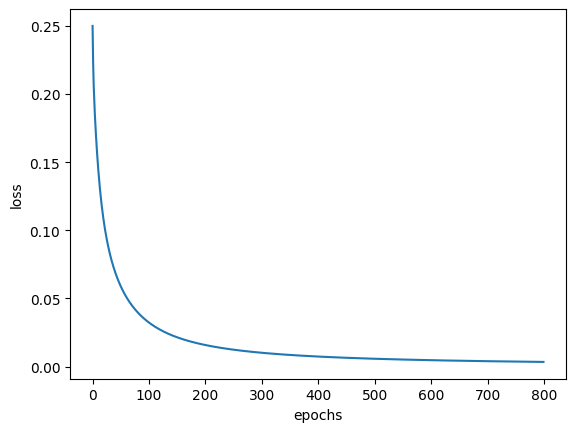

In [23]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [0, 0, 0, 1]

a = 0.5

perceptron = Perceptron()

train(perceptron, x, y, a, 800)

And now we can test the outputs of the model.

In [24]:
print('w1:', perceptron.w1, 'w2:', perceptron.w2, 'b:', perceptron.b)

for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

w1: 5.2148320270825455 w2: 5.2148320270825455 b: -7.916203592545897
0 0 -> 0.0004
0 1 -> 0.0629
1 0 -> 0.0629
1 1 -> 0.9251


Now the outputs are closer to the expected values.

Let's plot again and see what changes.

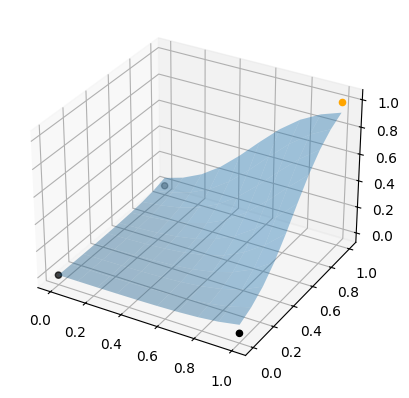

In [25]:
# sigmoid with numpy
def np_sigmoid(x):
    return 1 / (1 + np.exp(-x))

ax = plt.figure().add_subplot(projection='3d')

ax.scatter([0, 0, 1], [0, 1, 0], [0, 0, 0], color='black')
ax.scatter([1], [1], [1], color='orange')

# create grid
x = np.linspace(0, 1, 10)
y = np.linspace(0, 1, 10)
X, Y = np.meshgrid(x, y)

# sig(z = w1*x + w2*y + b)
Z = np_sigmoid(perceptron.w1 * X + perceptron.w2 * Y + perceptron.b)

ax.plot_surface(X, Y, Z, alpha=0.4)
plt.show()

Now our perceptron is modeling a curved surface instead of a plane. This can better adapt the model to the data.

## Multi Layer Perceptron

Since our perceptron models the AND function well, let's test it in another logical function, the XOR function.

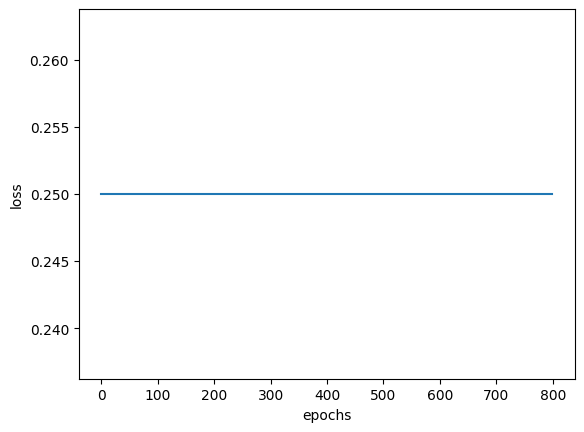

In [26]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [0, 1, 1, 0]

a = 0.5

perceptron = Perceptron()

train(perceptron, x, y, a, 800)

Now the loss is not going down. What's going on? Let's see the outputs of the model.

In [27]:
print(perceptron.w1, perceptron.w2, perceptron.b)

for (x1, x2), y1 in zip(x, y):
    o = perceptron.forward(x1, x2)
    print(f'{x1} {x2} -> {o:.4f}')

0.0 0.0 0.0
0 0 -> 0.5000
0 1 -> 0.5000
1 0 -> 0.5000
1 1 -> 0.5000


The outputs are all the same; the model is not learning at all. The AND function is a class of decision problems that have the property of linear separability. That means that we can draw a line that divides all classes of points on one side and the other class on the other side. Since our perceptron acts as a classifier in this example (correctly labeling a set of points), the line learned by the model is called the decision boundary.

Let's see this in the next plot:

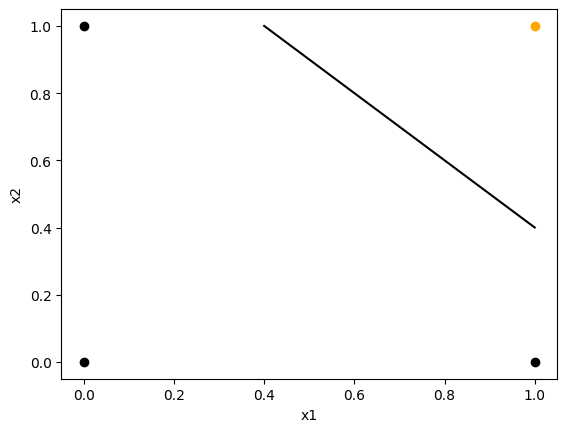

In [28]:
# the pairs that have output = 0
plt.scatter([0, 0, 1], [0, 1, 0], color='black', zorder=1)

# the pair that has the output = 1
plt.scatter([1], [1], color='orange', zorder=1)
plt.xlabel('x1')
plt.ylabel('x2')

# the line
plt.plot([0.4, 1], [1, 0.4], color='black', zorder=2)
plt.show()

For the XOR function, we need more than one line to correctly classify our points.

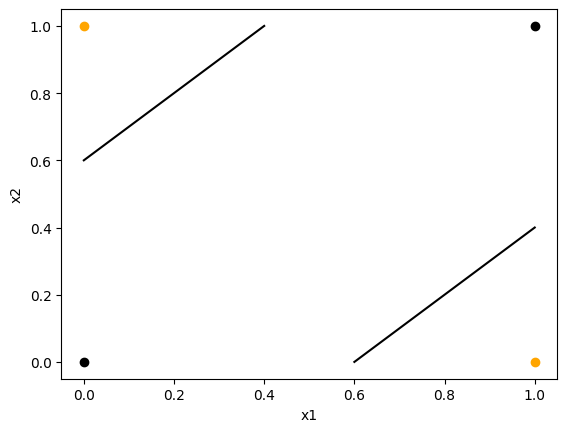

In [29]:
# the pairs that have output = 0
plt.scatter([0, 1], [0, 1], color='black', zorder=1)
# the pair that has the output = 1
plt.scatter([0, 1], [1, 0], color='orange', zorder=1)
plt.xlabel('x1')
plt.ylabel('x2')

# we need two lines to separate the data
plt.plot([0.0, 0.4], [0.6, 1.0], color='black', zorder=2)
plt.plot([0.6, 1], [0.0, 0.4], color='black', zorder=2)

plt.show()

Since our perceptron can only model a line, we need to improve its capacity of representation to deal with the XOR function. To solve this, we can compose multiple functions together to approximate any continuous function. This is called the Universal approximation theorem. Again, with inspiration from the brain, the neurons don't work alone, but they are combined as input to a neuron whose output will also serve as input to another group of neurons.

To simplify this abstraction, let's first consider the way our perceptron works. The output of our perceptron is defined as:

$$ o = \sigma(w_1x_1 + w_2x_2 + b) $$

If we treat our input as a vector $ \vec{X} = [x_1, x_2] $ and treat our perceptron weights also as a vector $ \vec{W} = [w_1, w_2] $. Then, our output can be represented as the dot product of those vectors, added by the bias, and then fed to the activation function:

$$ o = \sigma(\vec{X} \cdot \vec{W}^T + b) $$

Let's see one example:

In [30]:
# input matrix
x = [0, 1]
# weight matrix
w = [1, 1]

# our bias
b = [0]

o = [w[0] * x[0] + w[1] * x[1] + b[0]]
print(o)

[1]


To make it easier for us, let's define a matrix multiplication function:

In [31]:
def matmul(a, b):
    mat = [[0 for _ in range(len(b[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(b[0])):
            for k in range(len(a[0])):
                mat[i][j] += a[i][k] * b[k][j]

    return mat

Now we can just apply the matrix multiplication in the input and the weights:

In [32]:
# 1 x 2 input vector
x = [[0, 1]]

# 2 x 1 weight vector
# representing as a column vector so we don't need transposition
w = [[1],
      [1]]

print(matmul(x, w))

[[1]]


We can also define a matrix addition for our bias:

In [33]:
def add(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] + b[i][j]

    return mat

In [34]:
# 1 x 2 input vector
x = [[0, 1]]

# 2 x 1 weight vector
# representing as a column vector so we don't need transposition
w = [[1],
     [1]]

# 1 x 1 bias
b = [[1]]

print(add(matmul(x, w), b))

[[2]]


The advantage of this approach is that now the code is the same regardless of the shape of our vectors. This will help us in creating networks with arbitrary weights.

We can also put everything into a class to easy use, as those linear transformations will be frequent.

In [35]:
class Linear:

    # constructor with input and output sizes
    def __init__(self, inp, out):
        # weights
        self.w = [[0 for _ in range(out)] for _ in range(inp)]
        # bias
        self.b = [[0 for _ in range(out)]]

    def forward(self, x):
        # w_1x_1 + ... + w_nx_n + b
        return add(matmul(x, self.w), self.b)


x1 = [[0, 1]]
linear = Linear(2, 1)
print(linear.forward(x1))

[[0]]


Now, if we need to create multiple lines, this becomes easier.

In [36]:
linear1 = Linear(2, 1)
linear2 = Linear(2, 1)

x1 = [[0, 1]]

h1 = linear1.forward(x1)
h2 = linear2.forward(x1)

print(h1, h2)

[[0]] [[0]]


Another improvement is that two lines with one output are the same as one line with two outputs.


In [37]:
linear1 = Linear(2, 2)

h1 = linear1.forward(x1)

print(h1)

[[0, 0]]


Then we can stack multiple linear layers to combine them and produce a single output.

In [38]:
linear1 = Linear(2, 2)
linear2 = Linear(2, 1)

h1 = linear1.forward(x1)

h2 = linear2.forward(h1)

print(h2)

[[0]]


However, a linear transformation inside a linear transformation is still a linear transformation:

$$ h_1 = w_1x_1 + w_2x_2 + b $$

$$ h_2 = w_3h_1 + b $$

$$ h_2 = w_3(w_1x_1 + w_2x_2 + b) + b $$

$$ h_2 = w_3w_1x_1 + w_3w_2x_2 + (w_3b + b) $$

Adding those $w_3b + b$ is the same as just having another bias $b_3$.

$$ h_2 = w_3w_1x_1 + w_3w_2x_2 + b_3 $$

This is another reason why we need the activation function to achieve the non-linearity needed to build a universal function approximator.

For this, we need to apply the sigmoid function to each value of our vector.

In [39]:
# element-wise sigmoid
def sigmoid(x):
    mat = [[0 for _ in range(len(x[0]))] for _ in range(len(x))]

    for i in range(len(x)):
        for j in range(len(x[0])):
            mat[i][j] = 1 / (1 + math.exp(-x[i][j]))

    return mat

linear1 = Linear(2, 2)
linear2 = Linear(2, 1)

h1 = sigmoid(linear1.forward(x1))
h2 = sigmoid(linear2.forward(h1))

print(h2)

[[0.5]]


Now, we have all the ingredients to implement our model. Since our input is a matrix, we can also pass the whole dataset as input and compute its outputs in one pass. But to do this, since our bias is a single value, we need to repeat it for each new pair in the input. This operation is called broadcasting.

We can also override the __call__ method and use our linear layer as a function.

In [40]:
class Linear:

    def __init__(self, inp, out):
        self.w = [[0 for _ in range(out)] for _ in range(inp)]
        self.b = [[0 for _ in range(out)]]

    def forward(self, x):
        m = matmul(x, self.w)
        # broadcasting
        bb = [self.b[0] for _ in range(len(m))]
        return add(m, bb)

    # calling the linear as a function
    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

linear = Linear(2, 2)

# the whole dataset as input
# calling with forward
h1 = linear.forward(x)
print(h1)

# or as a function
h1 = linear(x)
print(h1)

[[0, 0], [0, 0], [0, 0], [0, 0]]
[[0, 0], [0, 0], [0, 0], [0, 0]]


To compute our gradients in the backward pass, we need to implement the other operations on the vectors.

In [41]:
def sub(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] - b[i][j]

    return mat

def pow(a, n):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] ** n

    return mat

def mul_s(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] * b

    return mat

def mul(a, b):
    mat = [[0 for _ in range(len(a[0]))] for _ in range(len(a))]

    for i in range(len(a)):
        for j in range(len(a[0])):
            mat[i][j] = a[i][j] * b[i][j]

    return mat

Now the same perceptron, but with the linear layer and the vector backward.

In [42]:
class Perceptron:

    def __init__(self, inp, out):
        self.linear1 = Linear(inp, out)

    def forward(self, x):
        return sigmoid(self.linear1(x))

    def backward(self, x, y):
        l1 = self.linear1(x)
        o = sigmoid(l1)

        de = mul_s(sub(y, o), 2)
        do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

        db = mul(de, do)

        dw = mul([q * len(x[0]) for q in db], x)

        return [[sum([q[i] for q in dw])] for i in range(len(dw[0]))], [[sum([q[0] for q in db])]]

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

We also need to update the train function.

In [43]:
def train(perceptron, x, y, a, epochs):

    lh = []
    for _ in range(epochs):

        o = perceptron(x)

        loss = sum(q[0] for q in pow(sub(y, o), 2)) / len(y)

        lh.append(loss)

        dw, db = perceptron.backward(x, y)

        perceptron.linear1.w = sub(perceptron.linear1.w, mul_s(dw, a))
        perceptron.linear1.b = sub(perceptron.linear1.b, mul_s(db, a))

    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

Now let's test if it works.

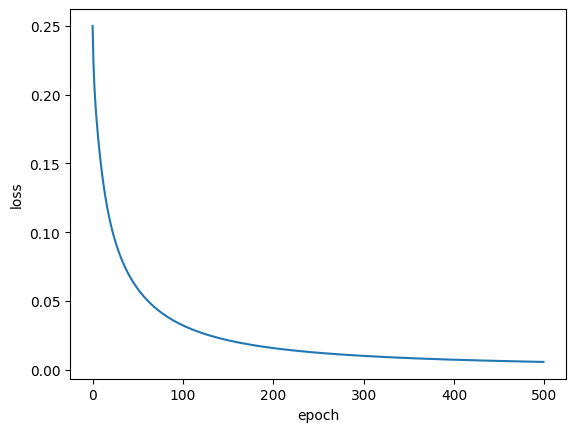

In [44]:
x = [(0, 0),
     (0, 1),
     (1, 0),
     (1, 1)]

y = [[0], [0], [0], [1]]

a = 0.5

perceptron = Perceptron(2, 1)

train(perceptron, x, y, a, 500)

In [45]:
print(perceptron.linear1.w, perceptron.linear1.b)

for x1, y1 in zip(x, y):
    o = perceptron([x1])
    print(f'{x1} -> {o[0]}')

[[4.646713304738055], [4.646713304738055]] [[-7.067441931349512]]
(0, 0) -> [0.0008516848626281008]
(0, 1) -> [0.08160563105078451]
(1, 0) -> [0.08160563105078451]
(1, 1) -> [0.902558796204585]


Works as expected.

To deal with the XOR function, we need to compose functions or stack multiple linear layers. This new model is called a Multi-Layer Perceptron. It is similar to the Perceptron but with more layers:

In [46]:
class MLP:

    def __init__(self, inp, out):
        # first layer outputs 4 values that will be input to the next layer
        self.linear1 = Linear(inp, 4)
        # (w1, w2, w3, w4) + bias
        self.linear2 = Linear(4, out)

    def forward(self, x):
        # compute the output of the first layer
        h1 = sigmoid(self.linear1(x))
        # now the output of the first layer is the input of the last layer
        return sigmoid(self.linear2(h1))

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

We run it in the same way we run the Perceptron:

In [47]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

o = mlp(x)

print(o)

[[0.5], [0.5], [0.5], [0.5]]


Now the hard work: computing the backward pass. We already know how to compute the gradients of the last layer since they are the same as the previous perceptron. To propagate those gradients to the next layer, we just keep following the chain rule and multiplying the gradients from previous layers by those local gradients of the last layer:

While our weights are inside only one matrix, let's consider them as two different lines, and let's label each sigmoid function to simplify our computing:

$$ h_1 = \sigma_1(w_1x_1 + w_2x_2 + b_1) $$
$$ h_2 = \sigma_2(w_3x_1 + w_4x_2 + b_2) $$

Now the second layer:

$$ h_3 = w_5h_1 + w_6h_2 + b_3 $$
$$ o = \sigma_3(h_3) $$

And finally, our loss:

$$ loss = (y - o) ^ 2 $$

Let's start computing our gradients:

$$ \frac{dloss}{do} = 2(y - o) $$

$$ \frac{do}{d\sigma_3} = - (\sigma(h_3) \cdot (1 - \sigma(h_3)) $$

And then the local gradient of the $w_5$ with respect to $\sigma_3$:

$$ \frac{\sigma_3}{dw_5} = h_1 $$

Now the gradient with respect to the loss is just a multiple of the previous local gradients:

$$ \frac{dloss}{dw_5} = \frac{dloss}{do} \cdot \frac{do}{d\sigma_3} \cdot * \frac{d\sigma_3}{dw_5} $$

Substituting it:

$$ \frac{dloss}{dw_5} = 2(y - o) \cdot (- (\sigma(h_3) \cdot (1 - \sigma(h_3))) \cdot h_1 $$

Now for $w_6$ and $b_3$:

$$ \frac{dloss}{dw_6} = 2(y - o) \cdot (- (\sigma(h_3) \cdot (1 - \sigma(h_3))) \cdot h_2 $$

$$ \frac{dloss}{db_3} = 2(y - o) \cdot (- (\sigma(h_3) \cdot (1 - \sigma(h_3))) $$

Continuing to compute $dw_1$:

$$ \frac{dh_3}{d\sigma_1} = w_5 \cdot \sigma(h_1) \cdot (1 - \sigma(h_1)) $$

$$ \frac{d\sigma_1}{dw_1} = x_1 $$

The other weights follow the same pattern. Let's implement them in code:

In [48]:
def backward(self, x, y):
    l1 = self.linear1(x)
    h1 = sigmoid(l1)
    l2 = self.linear2(h1)
    o = sigmoid(l2)

    # loss gradient
    d_loss = mul_s(sub(y, o), 2)

    # output gradient
    do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

    # second layer bias gradient
    db2 = mul(d_loss, do)
    # second layer weight gradient
    dw2 = mul([q * len(h1[0]) for q in db2], h1)

    # second layer gradient
    dl2 = mul([q * len(self.linear2.w) for q in db2], [[q[0] for q in self.linear2.w] for _ in db2])

    # first layer bias gradient
    db1 = mul(dl2, mul(h1, sub([[1] * len(h1[0]) for _ in h1], h1)))

    # broadcast second layer gradient
    bd1 = [[q] * len(x[0]) for q in db1]

    # broadcast input
    bx = [[[w] * len(bd1[0][0]) for w in q] for q in x]

    # first layer weight gradient
    dw1 = [mul(q, w) for q, w in zip(bd1, bx)]

    # now we average the gradients
    gb2 = [[sum(q[0] for q in db2)]]
    gw2 = [[sum([d[i] for d in dw2])] for i in range(len(dw2[0]))]
    gb1 = [[sum([d[i] for d in db1]) for i in range(len(db1[0]))]]
    gw1 = [[sum(e[q][j] for e in dw1) for j in range(len(dw1[0][0]))] for q in range(len(dw1[0]))]

    return gw1, gb1, gw2, gb2

MLP.backward = backward

Now update the training function to update all weights:

In [49]:
def train(model, x, y, a, epochs):

    lh = []
    for _ in range(epochs):

        o = model(x)
        lh.append(sum([x[0] for x in pow(sub(y, o), 2)]) / len(y))

        jw1, jb1, jw2, jb2 = model.backward(x, y)

        model.linear2.b = sub(model.linear2.b, mul_s(jb2, a))
        model.linear2.w = sub(model.linear2.w, mul_s(jw2, a))
        model.linear1.b = sub(model.linear1.b, mul_s(jb1, a))
        model.linear1.w = sub(model.linear1.w, mul_s(jw1, a))

    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

Now we can train and see if it works:

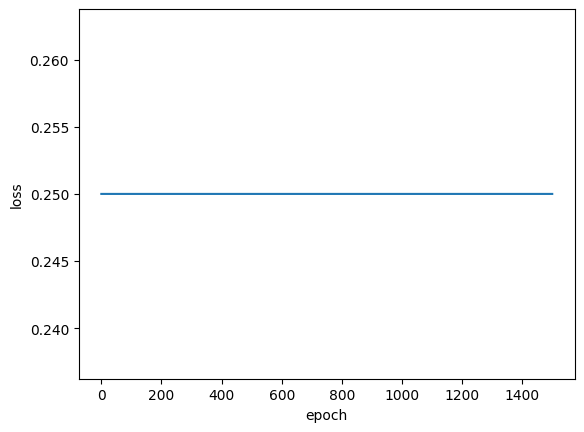

In [50]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

train(mlp, x, y, 0.1, 1500)

Strange, our model is still not learning. But our code is correct. What can be happening?

Let's see the model output:

In [51]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.5]
[0, 1] -> [0.5]
[1, 0] -> [0.5]
[1, 1] -> [0.5]


Debugging neural models is a hard task because it won't tell us what is wrong in the code. We need to search for expected behaviour and try to find the source of the problem.

Let's check the gradients of a new model:

In [52]:
mlp = MLP(2, 1)

jw1, jb1, jw2, jb2 = mlp.backward(x, y)

print(jw1, jb1, jw2, jb2)

[[0.0, 0.0, 0.0, 0.0], [0.0, 0.0, 0.0, 0.0]] [[0.0, 0.0, 0.0, 0.0]] [[0.0], [0.0], [0.0], [0.0]] [[0.0]]


All gradients are 0. We found the path to solve our problem. Zero gradients means that there is no signal to update our weights.

Let's compute the gradients of the output to see if we can find the problem:

In [53]:
# local gradient of loss
de = mul_s(sub(y, o), 2)

# local gradient of output
do = mul_s(mul(o, sub([[1] for _ in o], o)), -1)

# gradient of the loss with respect to the output
db2 = mul(de, do)
print(db2)

[[0.25], [-0.25], [-0.25], [0.25]]


The gradients are not zero. But look at them. At the last step, when we average those gradients, they will cancel out and become zero.

Let's check this:

In [54]:
print(sum(q[0] for q in db2))

0.0


The problem in this case is that because of the nature of the data and the output of our model, the average of the gradients is zero. One way to simply solve this problem is by introducing small variations in the initial gradient to give us the signal needed for the learning of our model.

To introduce those variations, instead of initializing our weights and biases in the linear layers to 0, we can choose a random value to start.

In this way, the probability of having zero gradients at the start due to the nature of the data is very low.

In [55]:
class Linear:

    def __init__(self, inp, out):
        # random initialization of our weights
        self.w = [[random.random() for _ in range(out)] for _ in range(inp)]
        # random initialization of our biases
        self.b = [[random.random() for _ in range(out)]]

    def forward(self, x):
        m = matmul(x, self.w)
        # broadcasting
        bb = [self.b[0] for _ in range(len(m))]
        return add(m, bb)

    def __call__(self, *args, **kwargs):
        return self.forward(*args, **kwargs)

Testing again:

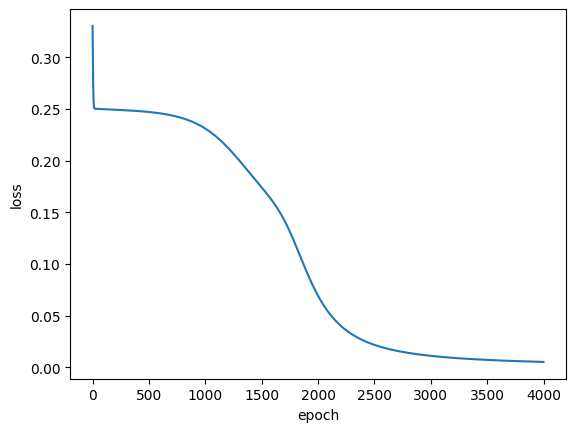

In [56]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[0], [1], [1], [0]]

train(mlp, x, y, 0.1, 4000)

Now it works. Let's also check the model outputs.

In [57]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.03267322932871577]
[0, 1] -> [0.9287246761240893]
[1, 0] -> [0.9245208156682658]
[1, 1] -> [0.09266185313639744]


The outputs are what we expect. We can also check the surface learned by our model.

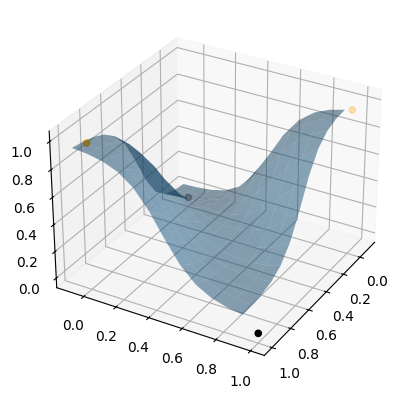

In [58]:
ax = plt.figure().add_subplot(projection='3d')

ax.scatter([0, 1], [0, 1], [0, 0], color='black')
ax.scatter([1, 0], [0, 1], [1, 1], color='orange')

# create grid
grid = []
for x1 in range(-1, 11):
    for x2 in range(-1, 11):
        grid.append([x1 / 10, x2 / 11])

o = [q[0] for q in mlp(grid)]

shape = (12, 12)
X = np.array([q[0] for q in grid]).reshape(shape)
Y = np.array([q[1] for q in grid]).reshape(shape)
Z = np.array(o).reshape(shape)

ax.plot_surface(X, Y, Z, alpha=0.5)
ax.view_init(elev=30, azim=30)
plt.show()

Our model fits our data by creating a valley with two peaks, where the points are 1. All the learning with those neural model are about modeling the right surface to fit our data.

Let's test again with the logical function NAND.

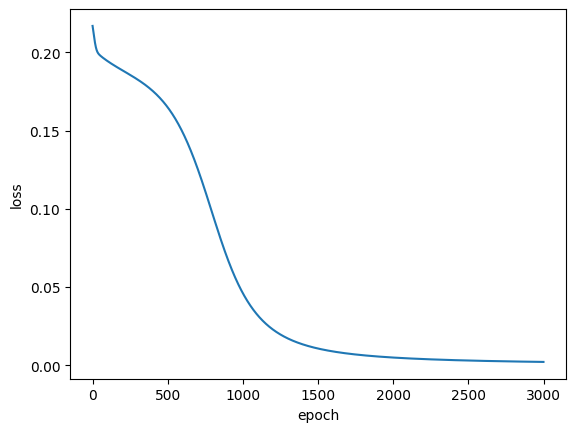

In [59]:
mlp = MLP(2, 1)

x = [[0, 0],
     [0, 1],
     [1, 0],
     [1, 1]]

y = [[1], [1], [1], [0]]

train(mlp, x, y, 0.1, 3000)

In [60]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

[0, 0] -> [0.9943086703609907]
[0, 1] -> [0.951903197721502]
[1, 0] -> [0.9519758837361106]
[1, 1] -> [0.061036604481093375]


Works as well with the NAND gate. This one is an interesting logical function because modern CPUs are all built from combinations of multiple NAND as we can build the other logic functions using only NAND gates.

Question to the reader:

Are neural networks Turing-complete since we can approximate a NAND gate with them?

# Autograd

Adding more layers to our model gives it more representation power. However, it also makes it difficult to implement the backward pass, as for each layer we need to manually write the gradient computations for them. To make this approach scalable for hundreds of layers, we must consider a way of automatically computing the gradients of each weight.

We have a way of solving this problem by taking advantage of how the chain rule works. With the chain rule, the derivatives are computed by accumulating the gradients from previous layers and multiplying them with local gradients, then propagating them back into the inputs of the computation. This is why this learning algorithm is called backpropagation. This structure forms a graph called a computation graph. We can compute the gradients with respect to each parameter by navigating backwards through this graph. Let's see the example of the computation graph of the AND function in the forward pass:

![](https://mermaid.ink/img/pako:eNptkUFPhDAQhf8KmQuJsgS6baE9GBM96sWj4dK1FYiUkgLZXQn_3S4F3U3spf3mzXtNZib4MFIBh9KKrgpe3oo2cOeUBrvdQ6DTxylsxEE1IQ_vwtmLx01ce5FH9G_vJnrU3tpf595vvRqtosfDDfWrsy49nz1e5ey2HNfjxRUX6MzRI_pDX_A3RG4EtQQ-2FFFoJXV4oIwXdQChkppVQB3TynsVwFFOztPJ9p3Y_Rms2YsK-CfoukdjZ0Ug3quhRuu_q1a1Upln8zYDsBpTpcQ4BOcgGPEYkIwJnuMUJLjCM7AU4biLCU5JglmDFE2R_C9fJrEhNKMMIb3jKKEZSgCJevB2Fe_1WW58w9leIYY?type=png)

By propagating back the gradients in this graph, we solve our problem:

![](https://mermaid.ink/img/pako:eNp1kztvgzAQgP-KdQt5QIQdG7CHKlI7tkvHisUpboIaHiIgSFH-e22cJlFbM52_7-6MT_YI71WmQMCukfUevT6nJdJfXfVI4U0QIDI7BdUcBcEDIneO_HKBdQFSa2PwBE9XSA0MLD3mO8t1gBQz5jhbztECzXTCFNueS5u2RCq69SzwZvQOcqsOnkDewjtfk-K7JOJKSm5JWwsLjBQ3tLd4wDeOQyMGK_ofQbSYZtMTW0HuxDSYwYr-IvQkR1nmhWyVQG3Tqcv_6Cn-z9cOTh2cOXjk4LGDJw7OHVzPxyFcJ8Z_jgy-vnt5BsKsfChUU0izhNGUpNDuVaFSEDrMZPOZQlqamlqWb1VV_JQ1Vbfbg_iQh6NedXWmN3jKpb7VxZU2qsxU81h1ZQuCEEymLiBGGEBQwleMUcrWlJAwoT6cQGBOVjFmCWUh5ZxE_OzD17RruGJRFDPO6ZpHJOSxbqayvK2aF_uepmd1_gZptfUQ?type=png)

You can learn more about this technique in this [YouTube video](https://youtu.be/VMj-3S1tku0?si=uil5F1BfkH0MwoB0) by Andrej Karpathy. The following implementation is inspired by his code.

First, let's create a class to store a value. In this example, we will consider only singular scalar values for simplicity.

In [61]:
# our value class
class Value:

    def __init__(self, data, children=(), local_grad=()):
        # the actual data
        self.data = data
        # the gradient will be filled later
        self.grad = 0
        # the children of this computation
        self.children = children
        # local gradients
        self.local_grad = local_grad

    # fancy print
    def __repr__(self):
        return f'Value({self.data}, {self.grad})'

Now, for each operation with this value, we need to store the operations that gave rise to it. Also, we store the local gradients of the current operation that will be multiplied with the propagated gradients from parent operations and then propagated to each corresponding child. Let's consider the computation of the addition:

Let's consider the variables $x_1$ and $x_2$. The new value is computed by $x_3 = x_1 + x_2$. The children of this new value $x_3$ are $x_1$ and $x_2$. Note that in the forward pass, those values are the parents of the new value. But, since in the back pass the gradients flow back in the graph, they are now the children. And then the local gradients of addition. Since the derivative of the sum is the sum of the derivatives, this has the same effect as copying the gradients back in the graph. In this case, the local gradient is 1 for both children. We can implement this with:

```python
def add(a, b):
    return Value(a + b, children=(a, b), local_grad=(1, 10))
```

We can also make it easier to use by overriding the method __add__ in our Value class to be able to use the + operator like this:

```python
a = Value(1)
b = Value(2)
c = a + b
```

In this way, the addition function will be:

In [62]:
def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return Value(self.data + other.data, children=(self, other), local_grad=(1, 1))

Implementing the other operators:

In [63]:
def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    return Value(self.data * other.data, children=(self, other), local_grad=(other.data, self.data))

def __radd__(self, other):
    return self + other

def __neg__(self):
    return self * -1

def __sub__(self, other):
    return self + (-other)

def __rsub__(self, other):
    return other + (-self)

def __pow__(self, power, modulo=None):
    return Value(self.data ** power, children=(self,), local_grad=(power * self.data ** (power - 1),))

Value.__add__ = __add__
Value.__radd__ = __radd__
Value.__neg__ = __neg__
Value.__sub__ = __sub__
Value.__rsub__ = __rsub__
Value.__mul__ = __mul__
Value.__pow__ = __pow__

Now we just need to implement the backpropagation step. To simplify our implementation, let's consider that only acyclic graphs will be used and there is no need for gradient accumulation. In this case, we only need to multiply the local grad with the gradients coming from the parent and recursively pass the gradient to its children.

In [64]:
# only acyclic graphs
def backward(self, grad=1):
    # filling the grad variable with the gradient at this point
    self.grad = grad

    # recursively passing the gradient to each child
    for c, lg in zip(self.children, self.local_grad):
        c.backward(grad * lg)

Value.backward = backward

And that's it. Now we can test with our first line example for simplicity:

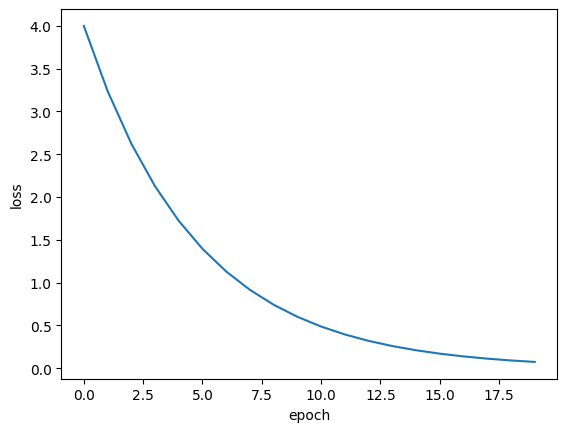

Model output 4.756846690818861


In [65]:
x = 2
y = 5

# our weights wrapped in the value class for automatic gradient
w = Value(1)
b = Value(1)

# learning rate
a = 0.01

lh = []
for _ in range(20):
    # as we override the arithmetic operations in the value class
    # We can work with our weights as if they are numbers
    o = w * x + b
    loss = (y - o) ** 2

    # and to compute the gradients, we just need to backpropagate them
    loss.backward()

    lh.append(loss.data)

    # after calling backward, each weight now have is gradient
    w.data -= 0.01 * w.grad
    b.data -= 0.01 * b.grad

plt.plot(lh)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

# testing with the learned weights
print('Model output', w.data * x + b.data)

With autograd, we don't need to implement the backward pass every time we create a new architecture. However, our simple example isn't robust enough to deal with complex computation graphs. Also, we need to implement all math operations and their local derivatives. The good part is that we don't need to reinvent the wheel here because a very good library that solves those problems already exists. One of those is PyTorch.

## PyTorch

PyTorch is a library built to create and train deep learning models. Let's walk through some of its features to discover how it works.


In [66]:
import torch

a = torch.Tensor([1, 2])
print(a + 2)

tensor([3., 4.])


The basis of PyTorch is the Tensor class. A tensor is a multidimensional array of data that implements linear algebra operations for us. In the same way, we implemented our multi-layer perceptron with weight matrices. Due to the need for high performance in some applications like games and computer graphics that use a lot of linear algebra operations, some specialized hardware like GPUs and parallel computing elements in CPU (SIMD) accelerate the computation of such operations. And good for us, PyTorch has integration with such technologies seamlessly. Let's compare the time to sum two matrices together with 10 million elements each.

In [67]:
import time

# two matrices with 10 million elements each
a1 = [[i for i in range(10_000_000)]]
a2 = [[i for i in range(10_000_000)]]

start = time.time()
add(a1, a2)
implementation_time = time.time() - start
print('Our time:', implementation_time)

t1 = torch.Tensor(a1)
t2 = torch.Tensor(a2)

start = time.time()
t3 = t1 + t2
pytorch_time = time.time() - start
print('Pytorch time:', pytorch_time)
print(f'That is a {round(implementation_time / pytorch_time)}x improvement.')

Our time: 0.6642720699310303
Pytorch time: 0.00627446174621582
That is a 106x improvement.


Another tool is Torch Autograd. PyTorch computes automatic gradients for every operation in the tensor class. And it's robust enough to produce the computation graph for every operation. Let's compare PyTorch autograd with our Value autograd.

In [68]:
x = 2
y = 5

# first our Value implementation

w = Value(1)
b = Value(1)
o = w * x + b
loss = (y - o) ** 2
loss.backward()
print('Our implementation:', w.grad, b.grad)

# now with PyTorch

tw = torch.Tensor([1])
tb = torch.Tensor([1])
to = tw * x + b
loss = (y - o) ** 2
loss.backward()
print('Pytorch:', w.grad, b.grad)

Our implementation: -8 -4
Pytorch: -8 -4


And PyTorch gives us the same gradients, but is much more efficient. Also, PyTorch has a default implementation of various modules and tools to help in training neural networks. Let's recreate our MLP in PyTorch and train the XOR logical function. First, let's write the MLP class.

In [69]:
import torch.nn as nn # torch.nn contains multiple layers and modules used in neural architectures

# All PyTorch modules descend from nn.Module
class MLP(nn.Module):
    def __init__(self, inp, out):
        super().__init__()
        # PyTorch has a linear layer that works the same as the Linear class we implemented
        self.l1 = nn.Linear(inp, 4)
        self.l2 = nn.Linear(4, out)

    # The processing is also done in the forward method
    def forward(self, x):
        # PyTorch also has a lot of activation functions by default
        h1 = torch.sigmoid(self.l1(x))
        return torch.sigmoid(self.l2(h1))

And that's it. Similar to our implementation, but the backward pass is implemented by default with the autograd, and the __call__ method is also overridden to call forward for us. Now let's see how the training function changes with PyTorch.

In [70]:
def train(model, x, y, a, epochs):

    lh = []
    for _ in range(epochs):
        # We can use our module as a function
        o = model(x)
        loss = (y - o) ** 2
        loss = loss.sum()

        # computing the loss gradients
        loss.backward()

        # We can get the actual value from the tensor with Tensor.item. Similar to Value.data
        lh.append(loss.item())

        # Here we can iterate over all parameters in our module.
        # another advantage of extending nn.Module is that it automatically manages all parameters we declare
        for p in model.parameters():
            # adding the negative gradient
            p.data -= a * p.grad
            # We need to clean the gradients after the propagation
            # In PyTorch, the gradients accumulate after each backward
            p.grad.zero_()

    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

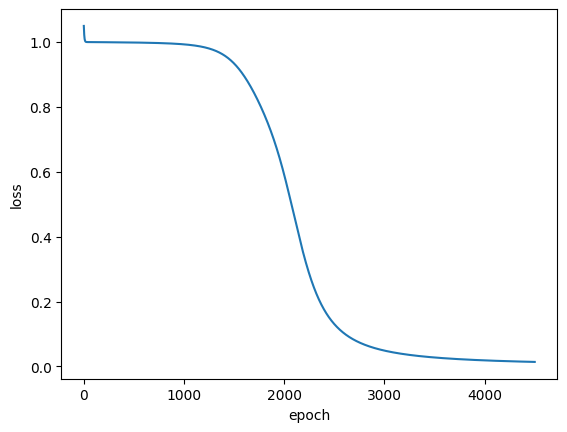

In [71]:
mlp = MLP(2, 1)

x = torch.Tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])

y = torch.Tensor([[0], [1], [1], [0]])

train(mlp, x, y, 0.1, 4500)

In [72]:
o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

tensor([0., 0.]) -> tensor([0.0585], grad_fn=<UnbindBackward0>)
tensor([0., 1.]) -> tensor([0.9443], grad_fn=<UnbindBackward0>)
tensor([1., 0.]) -> tensor([0.9336], grad_fn=<UnbindBackward0>)
tensor([1., 1.]) -> tensor([0.0540], grad_fn=<UnbindBackward0>)


Our module works in the same way, but note how the gradients are computed even when we are evaluating our model. In machine learning, we have multiple scenarios. One is when we are training our model with data. The other is when we deploy our model for its predictions. This step is called inference, and since we are not using the gradients here, we can be more efficient if we skip the gradient computation when doing inference. Remember that each computation stores the full computation graph in memory for the backward pass later. We can disable autograd by using the context management of torch.no_grad:

In [73]:
# gradients won't be computed
with torch.no_grad():
    o = mlp(x)

for x1, y1 in zip(x, o):
    print(f'{x1} -> {y1}')

tensor([0., 0.]) -> tensor([0.0585])
tensor([0., 1.]) -> tensor([0.9443])
tensor([1., 0.]) -> tensor([0.9336])
tensor([1., 1.]) -> tensor([0.0540])


We can improve further by applying a pre-defined loss function. Such as Mean Squared Error (MSE) loss. It computes the average of the squared error in the same way we are computing ours:

$$ mse = \frac{1}{n} \sum^n_{i=1} (y_i - o_i)^2$$

Also, we don't need to update the weights ourselves. We can use an optimizer for this. It will manage the weights updating, the learning rate, and other things. Let's update our training function:

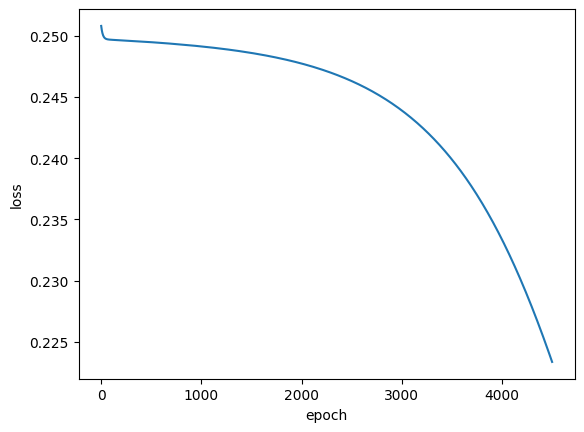

In [74]:
def train(model, x, y, lr, epochs):
    # our loss function
    crit = nn.MSELoss()

    # using Stochastic Gradient Descent optimizer
    # it takes as input the model parameters, and we pass the learning rate to it
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    lh = []
    for _ in range(epochs):
        # clean the gradients in each epoch
        optimizer.zero_grad()
        o = model(x)

        # same as torch.mean((y - o) ** 2)
        e = crit(y, o)

        loss = e.sum()
        loss.backward()

        lh.append(loss.item())

        # here the optimizer updates the weights
        optimizer.step()

    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()


mlp = MLP(2, 1)

x = torch.Tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])

y = torch.Tensor([[0], [1], [1], [0]])

train(mlp, x, y, 0.1, 4500)

Our training is taking a lot of epochs to converge. A lot of parameters can impact the speed of convergence in the model training. One of those is the choice of optimizer. A lot of techniques can improve the speed of convergence, and one of those is using momentum to compute the gradients. We can also tweak the learning rate over epochs. One of the optimizers with momentum that can speed up our training is Adam (Adaptive Moment Estimation).

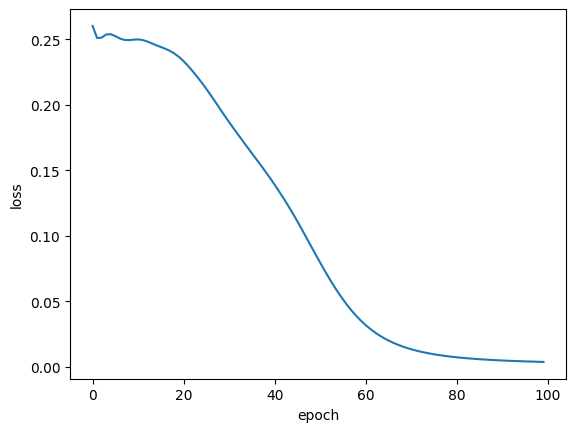

tensor([[0.0303],
        [0.9527],
        [0.9376],
        [0.0861]], grad_fn=<SigmoidBackward0>)


In [78]:
def train(model, x, y, lr, epochs):
    crit = nn.MSELoss()
    # We just plug Adam instead of SGD, and the rest of the code keeps the same.
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    for _ in range(epochs):
        optimizer.zero_grad()
        o = model(x)

        e = crit(y, o)

        loss = e.sum()
        loss.backward()

        lh.append(loss.item())

        optimizer.step()

    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()


mlp = MLP(2, 1)

x = torch.Tensor([[0, 0],
                  [0, 1],
                  [1, 0],
                  [1, 1]])

y = torch.Tensor([[0], [1], [1], [0]])

# training with 100 epochs
train(mlp, x, y, 0.1, 100)

print(mlp(x))

Instead of 4000 epochs with Adam, we trained our model with only 100 epochs.

# Classifier

Now that we have our tools to train a neural network, let's train a classifier. For this experiment, let's use the iris dataset. This dataset contains the attributes of 3 species of the iris flower:

<figure>
    <img src="https://oup.silverchair-cdn.com/oup/backfile/Content_public/Journal/jrssig/18/6/10.1111_1740-9713.01589/1/m_sign_18_6_26_fig-1.jpeg?Expires=1775781916&Signature=2ROdZHs2kGd-tVkofkVHJqJ4koKTuCXZPbT9LAFUNZNgaIQHjfj5u5~PDMVBwiNANiIU6~fY4PCG2ssPSycOizXbDcH2EUgAllNxBSx0PXLNif-thfi~mhaX53iyitg2gDJAaYt7slaCTnZ5v5wZNmZbU7Y7lzu03SnNsDCSdS7LfvdZegoXSLzr-5PThEIynfDFOmqE2AeqLMpgPPeRHKJ4ktwZS0PBrHhZUX2WooZrY2t1SR4Wqcjm69GYVPdNGVK4xp6hINDSzK-NaHpkalYX7jossqYNDnzwDP4QF626bSEqxCKYaMcxjYCHLzs9IIJ7kbR7RfqofWKyfTqKfg__&Key-Pair-Id=APKAIE5G5CRDK6RD3PGA" alt="Iris">
    <figcaption>Image from https://academic.oup.com/jrssig/article/18/6/26/7038520?login=false</figcaption>
</figure>

This dataset contains 50 samples of the 3 species Iris Setosa, Iris Versicolor, and Iris Virginica. Each sample contains 4 attributes: sepal length, sepal width, petal length, and petal width. Also, the target classes 0, 1, or 2 correspond to each species.

We can download this dataset from the scikit-learn library.

In [79]:
from sklearn.datasets import load_iris

iris = load_iris()

data = iris['data']
targets = iris['target']

Let's divide the dataset into training and test samples to evaluate it on data it wasn't trained on. The classifier is only useful if it can generalize to unseen data and give us the correct prediction. This division can help us with that.

In [80]:
x = torch.Tensor(data)
y = torch.Tensor(targets)

# shuffle data and split into train and test
perm = torch.randperm(len(x))
x = x[perm]
y = y[perm]

# 80% for training and 20% for test
train_size = int(0.8 * len(x))
x_train = x[:train_size]
y_train = y[:train_size]
x_test = x[train_size:]
y_test = y[train_size:]

To build a classifier, we need our model to assign the right class when we give the input features to it. This is the same as assigning a probability to all classes while giving a higher probability to the correct class. We can make our model produce a probability for each class by setting the output size in our matrix to the number of classes. However, as probability distributions need to sum to one, we can't use the sigmoid function as our activation function at the last layer. We can use instead the softmax function defined as:

$$ softmax(h) = \frac{e^{h_i}}{\sum^N_{j=1}e^{h_j}} $$

With this activation function, our output is normalized to 1 and represents a probability distribution. We can also make our implementation easier if we use the softmax function in log space, since we have the negative log likelihood, as it accepts an integer as the index of the expected higher class probability.

In [81]:
class Model(nn.Module):
    def __init__(self, inp, out):
        super().__init__()

        self.l1 = nn.Linear(inp, 4)
        self.l2 = nn.Linear(4, out)

    def forward(self, x):
        h1 = torch.sigmoid(self.l1(x))
        # everything the same, but we apply log_softmax instead of sigmoid at the last layer
        return torch.log_softmax(self.l2(h1), dim=-1)

Now we can train our model. One required modification is that for larger datasets, we need to compute a larger computation graph that will consume a higher amount of memory. Instead of computing the gradients of the entire dataset, we can estimate them by taking small samples of the dataset and learning in those. This strategy is called mini-batch gradient descent. And we have useful classes to implement this in PyTorch.

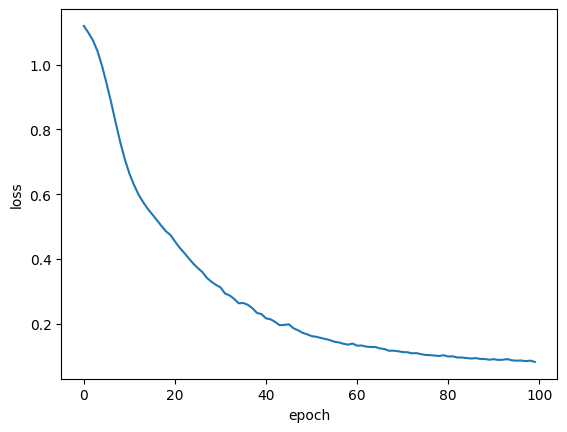

In [82]:
from torch.utils.data import DataLoader, TensorDataset

def train(model, data, lr, epochs):
    crit = nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    for _ in range(epochs):
        el = []
        # With the data loader, we can get small samples of the dataset
        for x, y in DataLoader(data, batch_size=16, shuffle=True):
            optimizer.zero_grad()
            o = model(x)

            e = crit(o, y)

            loss = e.sum()
            loss.backward()
            el.extend(loss.item() for _ in range(len(x)))

            optimizer.step()

        lh.append(sum(el) / len(el))

    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()


model = Model(4, 3)

# training our model
# We can also use a tensor dataset to group our input features and output features from the train dataset
train(model, TensorDataset(x_train, y_train.long()), 0.01, 100)

Our model learned well, and now we can test it in the test dataset.

In [83]:
def test(model, data):
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in DataLoader(data, batch_size=16, shuffle=False):
            o = model(x)
            pred = o.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += len(x)

    print(f'Accuracy: {correct / total:.4f}')

test(model, TensorDataset(x_test, y_test.long()))

Accuracy: 1.0000


We can reach up to 100% accuracy depending on the division of the train and test datasets as they are shuffled.

## Image Classifier

In the previous example, we trained a classifier from plant features. If we had the pictures of the plants instead? Extracting those features automatically from images is a difficult task. With deep learning, we can directly give the image as input, and the model will learn how to extract those features. To build it, let's start with a dataset containing images. We will use the MNIST dataset. It is a dataset of handwritten digits with its labels. We can download it from torchvision.

In [84]:
from torchvision.datasets.mnist import MNIST

data = MNIST(root='./data', download=True)

In [85]:
print('Size of dataset:', len(data))

Size of dataset: 60000


Let's split 50000 samples for training and the rest for testing. Also, let's convert the data to torch tensors.

In [86]:
import numpy as np

si = torch.randperm(len(data))
data = [data[i] for i in si]
train_data = [(torch.from_numpy(np.array(x)).float(), torch.LongTensor([y])) for x, y in data[:50_000]]
tx, ty = zip(*train_data)
tds = TensorDataset(torch.stack(tx), torch.cat(ty))
test_data = [(torch.from_numpy(np.array(x)).float(), torch.LongTensor([y])) for x, y in data[50_000:]]
tx, ty = zip(*test_data)
test_ds = TensorDataset(torch.stack(tx), torch.cat(ty))

Let's take a look at one image:

torch.Size([28, 28])


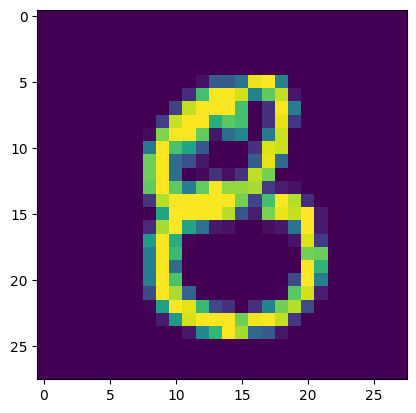

In [87]:
print(train_data[4][0].shape)
plt.imshow(train_data[4][0])
plt.show()

Now, we can build our model architecture. Our input is a 2D image, and to process it with the tools we have now, we need to convert it to a 1D feature vector. We can just concatenate each pixel row one after the other using the nn.Flatten. This will convert our 28x28 image to a vector of 784 dimensions. Also, since we will apply those operations one after the other, where the output of one layer is the input of another, we can group them into a sequential layer.

In [88]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, x):
        return self.seq(x)

  0%|          | 0/500000 [00:00<?, ?it/s]

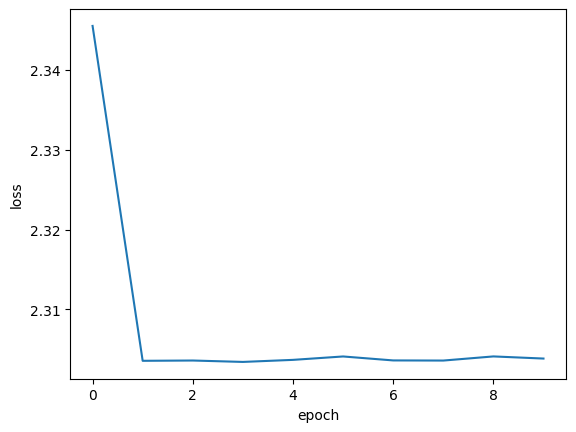

In [89]:
from tqdm.auto import tqdm

model = Model()

def train(model, data, lr, epochs, batch_size=8):
    crit = nn.NLLLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    # display a fancy progress bar, track the training
    progress = tqdm(total=len(data) * epochs)
    for _ in range(epochs):
        el = []
        for x, y in DataLoader(data, batch_size=batch_size, shuffle=True):
            optimizer.zero_grad()
            o = model(x)
            loss = crit(o, y)
            loss.backward()
            el.append(loss.item())

            optimizer.step()
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()


train(model, tds, 0.01, 10)

Now we can test our approach:

In [90]:
def test(model, data):
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in DataLoader(data, batch_size=16, shuffle=False):
            o = model(x)
            pred = o.argmax(dim=-1)
            correct += (pred == y).sum().item()
            total += len(x)

    print(f'Accuracy: {correct / total:.4f}')

test(model, test_ds)

Accuracy: 0.1001


Our model got a low accuracy of around 10%. To improve this accuracy, we need to understand how each layer transforms our data. Let's start with some random points:

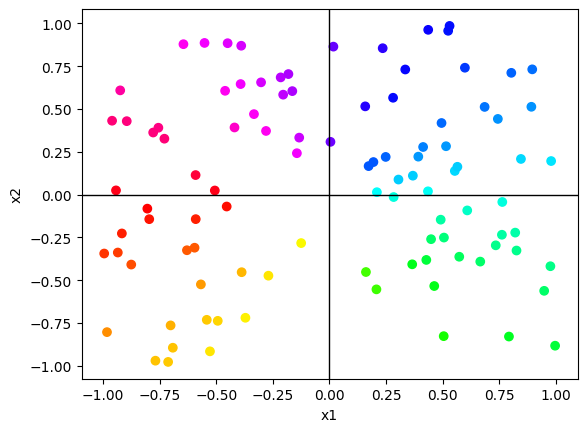

In [91]:
rx = torch.rand((100, 1)) * 2 - 1.0
ry = torch.rand((100, 1)) * 2 - 1.0

# color for each point based on its angle
colors = torch.atan2(ry, rx) / (2 * math.pi) + 0.5

plt.axhline(0, color='black', lw=1)
plt.axvline(0, color='black', lw=1)
plt.xlabel('x1')
plt.ylabel('x2')

plt.scatter(rx, ry, c=colors, cmap='hsv')

plt.show()

Now, let's apply a linear layer at those points to see what happens:

In [92]:
ln1 = nn.Linear(2, 2)

with torch.no_grad():
    o = ln1(torch.cat([rx, ry], dim=-1))

nrx = o[:, 0]
nry = o[:, 1]

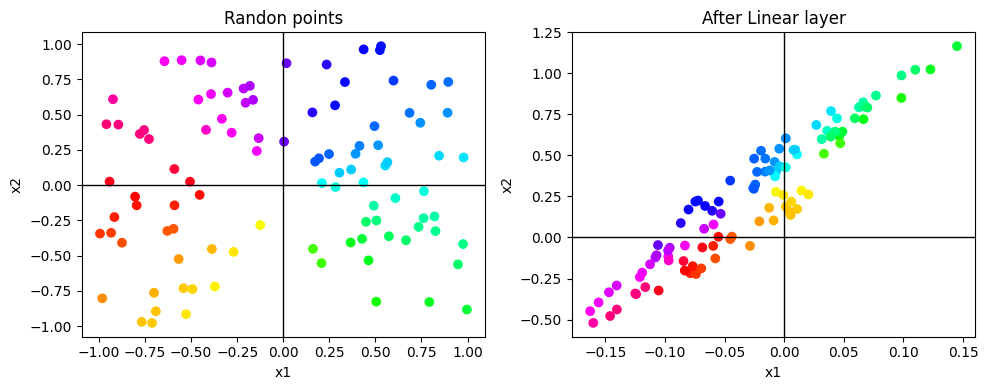

In [93]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].axhline(0, color='black', lw=1)
ax[0].axvline(0, color='black', lw=1)
ax[0].set_xlabel('x1')
ax[0].set_ylabel('x2')
ax[0].set_title('Randon points')

ax[0].scatter(rx, ry, c=colors, cmap='hsv')

ax[1].axhline(0, color='black', lw=1)
ax[1].axvline(0, color='black', lw=1)
ax[1].set_xlabel('x1')
ax[1].set_ylabel('x2')
ax[1].set_title('After Linear layer')

ax[1].scatter(nrx, nry, c=colors, cmap='hsv')

fig.tight_layout()
plt.show()

Our linear layer applied a rotation and scale to all dimensions. This gives us one direction of why our model is having problems in modeling our data. Our images are composed of pixels that range from 0 to 255. If we consider each pixel as a vector, applying a small rotation to a vector with a large magnitude can move the point to a large distance. To make it easy for the model, we need to keep the standard deviation of our data at 1, and since those rotations are around the origin, we need to keep our mean at 0. Let's also see how the sigmoid and ReLU activation functions change our data.

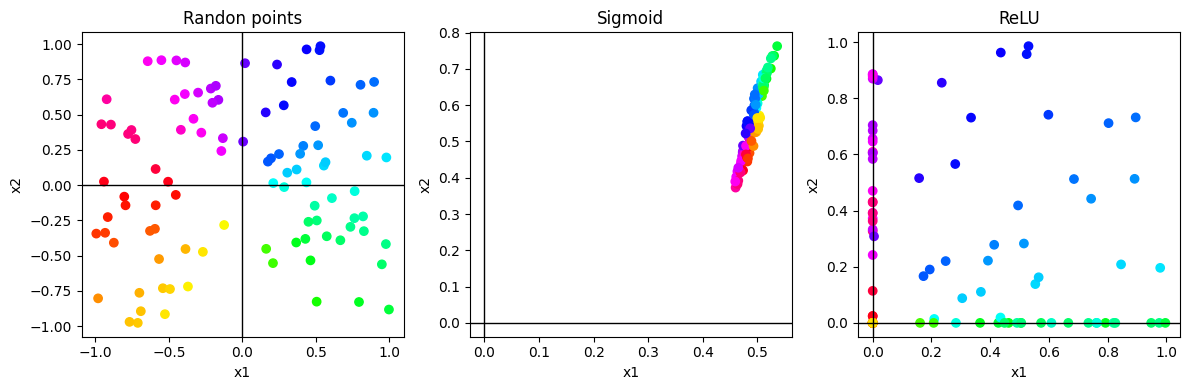

In [94]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))

ax[0].axhline(0, color='black', lw=1)
ax[0].axvline(0, color='black', lw=1)
ax[0].set_xlabel('x1')
ax[0].set_ylabel('x2')
ax[0].set_title('Randon points')

ax[0].scatter(rx, ry, c=colors, cmap='hsv')

ax[1].axhline(0, color='black', lw=1)
ax[1].axvline(0, color='black', lw=1)
ax[1].set_xlabel('x1')
ax[1].set_ylabel('x2')
ax[1].set_title('Sigmoid')

ax[1].scatter(torch.sigmoid(nrx), torch.sigmoid(nry), c=colors, cmap='hsv')

ax[2].axhline(0, color='black', lw=1)
ax[2].axvline(0, color='black', lw=1)
ax[2].set_xlabel('x1')
ax[2].set_ylabel('x2')
ax[2].set_title('ReLU')

o = torch.relu(torch.cat([rx, ry], dim=-1))

nrx = o[:, 0]
nry = o[:, 1]

ax[2].scatter(nrx, nry, c=colors, cmap='hsv')

fig.tight_layout()
plt.show()

The activation functions have a tendency to group the points together. For example, the sigmoid function clamps our points between 0 and 1, and the ReLU activation function moves our data to the first quadrant. You can learn more about the internal workings of neural networks at this great YouTube [video](https://youtu.be/-at7SLoVK_I?si=x2SSSM56XPhUTuHE).

Ok, now we know that our neural networks like normalized data, let's first normalize the data and then train our model again.

  0%|          | 0/500000 [00:00<?, ?it/s]

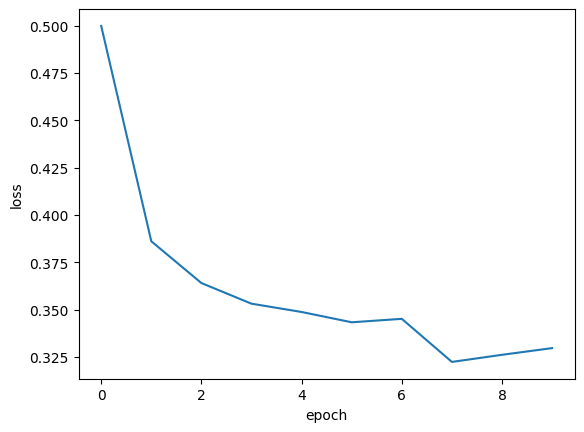

In [96]:
model = Model()

tx, ty = zip(*train_data)
tx = torch.stack(tx)
ty = torch.cat(ty)
tx = (tx - tx.mean()) / (tx.std() + 1e-8)
tds = TensorDataset(tx, ty)

train(model, tds, 0.01, 10)

In [97]:
test(model, test_ds)

Accuracy: 0.8077


That's a great improvement from 10% to over 75% accuracy. Let's see how we can improve even further. Let's take a look at our model's learned weights.

In [98]:
for name, p in model.named_parameters():
    with torch.no_grad():
        print(name, p.max(), p.min())

seq.1.weight tensor(7.7542) tensor(-14.1228)
seq.1.bias tensor(0.0578) tensor(-1.6560)
seq.3.weight tensor(1.6646) tensor(-3.7759)
seq.3.bias tensor(3.4076) tensor(-7.8281)
seq.5.weight tensor(0.4638) tensor(-5.4495)
seq.5.bias tensor(0.5855) tensor(-0.9071)


Due to the nature of gradient descent, our model often takes shortcuts to learn our data, and for this, it can increase the magnitude of our weights, leading to problems in generalization for unseen data. One technique that can help us in this is using a technique called Dropout. This technique randomly sets a subset of our weights to zero during training and can help with overfitting, as this can help distribute the work among the other weights. Let's apply dropout and compare the weights again after training.

  0%|          | 0/500000 [00:00<?, ?it/s]

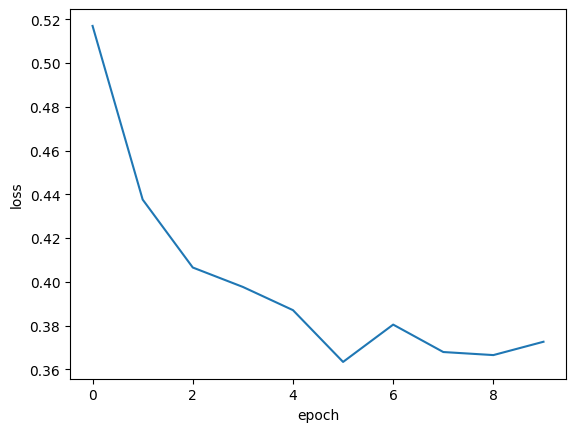

In [99]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 10),
            nn.LogSoftmax(dim=-1)
        )

    def forward(self, x):
        return self.seq(x)

model = Model()
train(model, tds, 0.006, 10)

In [100]:
# model.eval disable the dropout layers for evaluation
model.eval()

test(model, test_ds)

Accuracy: 0.8622


Our accuracy increased to over 80% accuracy using the dropout. And let's see the learned weights:

In [101]:
for name, p in model.named_parameters():
    with torch.no_grad():
        print(name, p.max(), p.min())

seq.1.weight tensor(5.2936) tensor(-9.0833)
seq.1.bias tensor(-0.0024) tensor(-1.2275)
seq.4.weight tensor(1.2317) tensor(-2.5466)
seq.4.bias tensor(2.4614) tensor(-7.9442)
seq.7.weight tensor(0.2299) tensor(-6.4686)
seq.7.bias tensor(0.5796) tensor(-0.6683)


The dropout reduced the norm of our weights. Helping our model generalize.

## Autoencoder

In this course, we saw how to build a linear regressor, binary classifiers from AND logical functions, and multi-class classification. In those examples, the output of our model is labels or points. Can we build a model capable of generating images or text? One of the most important architectures capable of generating images is the Autoencoder. The autoencoder is trained to reconstruct its input. This is an interesting learning approach because in the classification examples, we have the features as input and an expected label, which our model needs to reach. This is called supervised learning because the labels are the supervision guiding the model's learning. In the autoencoder training, the model will reconstruct the input, and there is no other label than the input features. This type of learning is called unsupervised learning, where our model needs to learn hidden structures in our data.

Learning to reconstruct our data with enough weights is not an intuitive task because the model can just learn an identity function and simply copy the input to the output. However, in the autoencoder architecture, there is a data bottleneck where the model needs to produce a compressed representation of the input and use this compressed representation to reconstruct the data. The compressor part is also called the encoder, and the decompressor is called the decoder.

Let's build the autoencoder architecture:

  0%|          | 0/500000 [00:00<?, ?it/s]

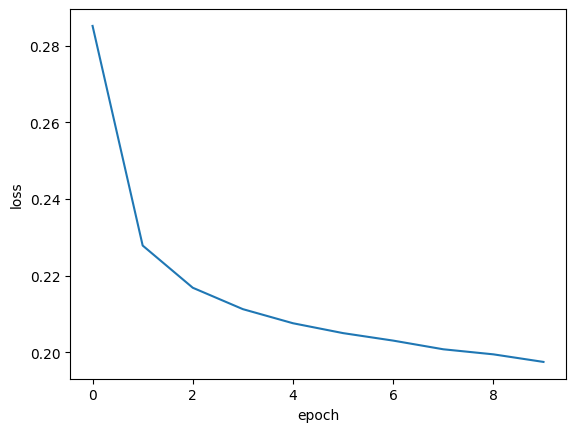

In [102]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        # Our encoder layer will gradually compress our image into lower dimensions from 784 dimensions down to 64
        self.enc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
        )
        # The decoder will reconstruct our input from 64 dimensions back to 784 dimensions
        # then we reshape our vectors back to a 28x28 size vector
        self.dec = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 28 * 28),
            nn.Unflatten(1, (28, 28))
        )

    def forward(self, x):
        h = self.enc(x)
        return self.dec(h)

def train(model, data, lr, epochs):
    # We use MSE loss to compare the reconstructed pixels from the input image
    crit = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    lh = []
    progress = tqdm(total=len(data) * epochs)
    for _ in range(epochs):
        el = []
        for x, _ in DataLoader(data, batch_size=8, shuffle=True):
            optimizer.zero_grad()
            o = model(x)
            loss = crit(o, x)
            loss.backward()
            el.append(loss.item())

            optimizer.step()
            progress.update(x.shape[0])

        lh.append(sum(el) / len(el))

    progress.close()
    plt.plot(lh)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.show()

model = Model()
# we need to use a small learning rate
train(model, tds, 0.0006, 10)

After the learning, we can test our autoencoder to see how well it is reconstructing our data.

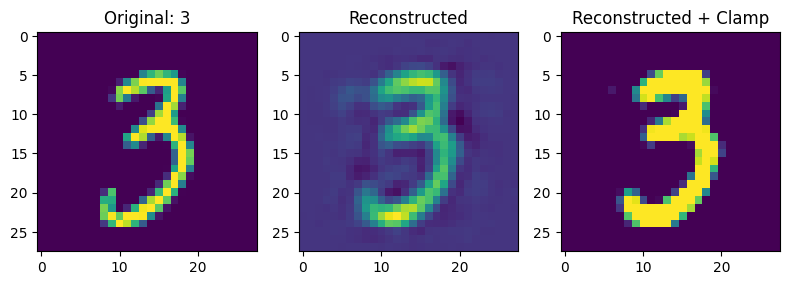

In [103]:
x, y = tds[0]

fig, ax = plt.subplots(1, 3, figsize=(8, 4))
ax[0].imshow(x)
ax[0].set_title(f'Original: {y.item()}')

with torch.no_grad():
    o = model(x.unsqueeze(0))[0]
ax[1].imshow(o)
ax[1].set_title('Reconstructed')

ax[2].imshow(torch.clamp(o, 0, 1))
ax[2].set_title('Reconstructed + Clamp')

fig.tight_layout()
plt.show()

Our model reconstructs the input with high fidelity. This simple approach has a vast range of applications. One of those is the denoising autoencoder, where the model is trained to reconstruct the input, but with noise added to the input image. Another option is working as a lossy data compression technique since we can encode our image and transmit the encoded tensor, and reconstruct it when needed. Other applications can be converting the input to black and white and training the model to recolor an image. Or scale the input image down and train the model to upscale an image.

## Conclusion

This introduction showed how we can train neural models to do classification and regression tasks. Also, we see simple techniques in debugging those models to improve their performance. And lastly, we saw how to train an autoencoder model that can reconstruct an input image. This is the starting point in the learning of a generative model capable of generating images or text.

In the next chapter, we will see how to reuse those techniques in building neural models capable of generating text and performing other tasks.